In [ ]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from midv_metadata import collect_midv_metadata, save_metadata

df_midv = collect_midv_metadata(midv_root)


In [7]:
from midv_suspicious_generation import generate_suspicious_images_on_document, save_metadata

df_midv_test = df_midv.sample(10, random_state=42)

generated_output_dir = project_root / "data" / "processed" / "midv_suspicious_test_images"
generated_metadata_path = project_root / "data" / "processed" / "midv_suspicious_test_metadata.csv"

df_midv_suspicious_test = generate_suspicious_images_on_document(
    metadata_df=df_midv_test,
    output_dir=generated_output_dir
)

print(df_midv_suspicious_test.head())
print(df_midv_suspicious_test.shape)

save_metadata(df_midv_suspicious_test, generated_metadata_path)

  source_dataset   source_type              doc_type          file_name  \
0           midv         photo          grc_passport  55_suspicious.jpg   
1           midv         photo          grc_passport  27_suspicious.jpg   
2           midv  scan_upright                svk_id  89_suspicious.jpg   
3           midv         photo                alb_id  70_suspicious.jpg   
4           midv  scan_rotated  rus_internalpassport  56_suspicious.jpg   

       file_stem                                         image_path  \
0  55_suspicious  c:\Users\Admin\Desktop\thesis\multimodal-fraud...   
1  27_suspicious  c:\Users\Admin\Desktop\thesis\multimodal-fraud...   
2  89_suspicious  c:\Users\Admin\Desktop\thesis\multimodal-fraud...   
3  70_suspicious  c:\Users\Admin\Desktop\thesis\multimodal-fraud...   
4  56_suspicious  c:\Users\Admin\Desktop\thesis\multimodal-fraud...   

                                 original_image_path  \
0  c:\Users\Admin\Desktop\thesis\multimodal-fraud...   
1  c:\User

In [8]:
print("Input images:", len(df_midv_test))
print("Generated suspicious images:", len(df_midv_suspicious_test))

Input images: 10
Generated suspicious images: 8


In [9]:
generated_originals = set(df_midv_suspicious_test["original_image_path"])
failed_rows = df_midv_test[~df_midv_test["image_path"].isin(generated_originals)]

print(failed_rows[["source_type", "doc_type", "file_name", "annotation_path"]])

     source_type doc_type file_name  \
3491   templates   fin_id    91.jpg   
3925   templates   svk_id    25.jpg   

                                        annotation_path  
3491  c:\Users\Admin\Desktop\thesis\multimodal-fraud...  
3925  c:\Users\Admin\Desktop\thesis\multimodal-fraud...  


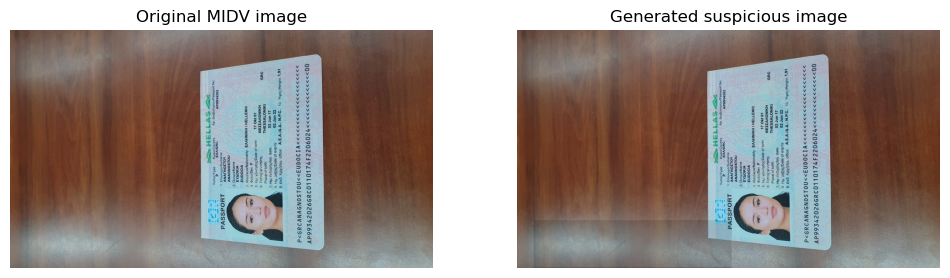

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

original_path = df_midv_suspicious_test.iloc[0]["original_image_path"]
generated_path = df_midv_suspicious_test.iloc[0]["image_path"]

img_original = Image.open(original_path)
img_generated = Image.open(generated_path)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_original)
plt.title("Original MIDV image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_generated)
plt.title("Generated suspicious image")
plt.axis("off")

plt.show()

An initial experiment was conducted to generate suspicious MIDV samples by applying controlled modifications to the document region. However, the resulting visual differences were not strong or realistic enough to support a robust suspicious class for the final dataset. Therefore, MIDV was retained as a source of bona fide images only, while FMIDV was considered as a more suitable source of manipulated document samples.